In [1]:
# ==========================================
# Credit Card Fraud Detection
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load datasets

train_df = pd.read_csv("dataset/fraudTrain.csv")
test_df = pd.read_csv("dataset/fraudTest.csv")

print("Train Shape :", train_df.shape)
print("Test Shape  :", test_df.shape)

Train Shape : (1296675, 23)
Test Shape  : (555719, 23)


In [3]:
# ==========================================
# Dataset Overview
# ==========================================

print("Training Dataset Information")
print("-" * 40)
train_df.info()

print("\nMissing Values")
print("-" * 40)
print(train_df.isnull().sum())

print("\nFraud Distribution")
print("-" * 40)
print(train_df["is_fraud"].value_counts())

print("\nFraud Percentage")
print("-" * 40)
print(train_df["is_fraud"].value_counts(normalize=True) * 100)

Training Dataset Information
----------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  str    
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  str    
 4   category               1296675 non-null  str    
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  str    
 7   last                   1296675 non-null  str    
 8   gender                 1296675 non-null  str    
 9   street                 1296675 non-null  str    
 10  city                   1296675 non-null  str    
 11  state                  1296675 non-null  str    
 12  zip                    1296675 non-null  int64  
 13  lat          

In [4]:
# ==========================================
# Remove Unnecessary Columns
# ==========================================

drop_columns = [
    "Unnamed: 0",
    "trans_date_trans_time",
    "cc_num",
    "merchant",
    "first",
    "last",
    "street",
    "city",
    "state",
    "zip",
    "job",
    "dob",
    "trans_num"
]

train_df = train_df.drop(columns=drop_columns)
test_df = test_df.drop(columns=drop_columns)

print("Remaining Columns:")
print(train_df.columns.tolist())

Remaining Columns:
['category', 'amt', 'gender', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']


In [5]:
# ==========================================
# Encode Categorical Features
# ==========================================

from sklearn.preprocessing import LabelEncoder

# Create encoders
category_encoder = LabelEncoder()
gender_encoder = LabelEncoder()

# Encode training data
train_df["category"] = category_encoder.fit_transform(train_df["category"])
train_df["gender"] = gender_encoder.fit_transform(train_df["gender"])

# Encode test data
test_df["category"] = category_encoder.transform(test_df["category"])
test_df["gender"] = gender_encoder.transform(test_df["gender"])

print("Encoding Completed Successfully!\n")

print(train_df.head())

Encoding Completed Successfully!

   category     amt  gender      lat      long  city_pop   unix_time  \
0         8    4.97       0  36.0788  -81.1781      3495  1325376018   
1         4  107.23       0  48.8878 -118.2105       149  1325376044   
2         0  220.11       1  42.1808 -112.2620      4154  1325376051   
3         2   45.00       1  46.2306 -112.1138      1939  1325376076   
4         9   41.96       1  38.4207  -79.4629        99  1325376186   

   merch_lat  merch_long  is_fraud  
0  36.011293  -82.048315         0  
1  49.159047 -118.186462         0  
2  43.150704 -112.154481         0  
3  47.034331 -112.561071         0  
4  38.674999  -78.632459         0  


In [6]:
# ==========================================
# Separate Features and Target
# ==========================================

X_train = train_df.drop("is_fraud", axis=1)
y_train = train_df["is_fraud"]

X_test = test_df.drop("is_fraud", axis=1)
y_test = test_df["is_fraud"]

print("Training Features Shape :", X_train.shape)
print("Testing Features Shape  :", X_test.shape)

print("\nFeature Names:")
print(X_train.columns.tolist())

Training Features Shape : (1296675, 9)
Testing Features Shape  : (555719, 9)

Feature Names:
['category', 'amt', 'gender', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long']


In [7]:
# ==========================================
# Train Random Forest Model (Baseline)
# ==========================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

print("Training the Random Forest model...")

rf_model.fit(X_train, y_train)

print("✅ Model trained successfully!")

Training the Random Forest model...
✅ Model trained successfully!


In [8]:
# ==========================================
# Model Evaluation
# ==========================================

y_pred = rf_model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.9973331845770974

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.88      0.36      0.51      2145

    accuracy                           1.00    555719
   macro avg       0.94      0.68      0.75    555719
weighted avg       1.00      1.00      1.00    555719



[[553473    101]
 [  1381    764]]


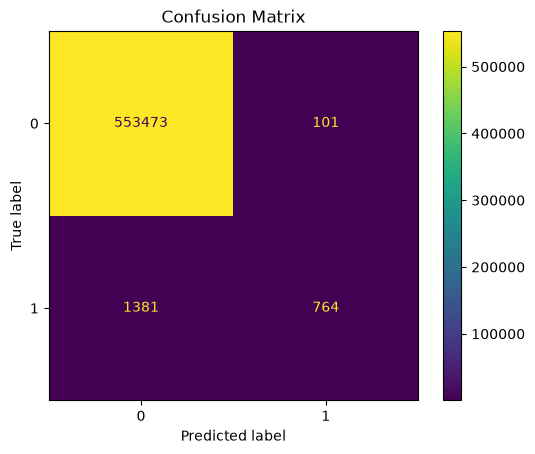

In [9]:
# ==========================================
# Confusion Matrix
# ==========================================

cm = confusion_matrix(y_test, y_pred)

print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()

In [10]:
# ==========================================
# Save the Trained Model
# ==========================================

import joblib

joblib.dump(rf_model, "fraud_model.pkl")

print("✅ Model saved successfully!")

✅ Model saved successfully!


In [11]:
# ==========================================
# Save Label Encoders
# ==========================================

joblib.dump(category_encoder, "category_encoder.pkl")
joblib.dump(gender_encoder, "gender_encoder.pkl")

print("✅ Encoders saved successfully!")

✅ Encoders saved successfully!


In [16]:
train_df[train_df["is_fraud"] == 0][[
    "category",
    "gender",
    "amt",
    "city_pop",
    "lat",
    "long",
    "merch_lat",
    "merch_long",
    "unix_time"
]].head(1)

,category,gender,amt,city_pop,lat,long,merch_lat,merch_long,unix_time
0,8,0,4.97,3495,36.0788,-81.1781,36.011293,-82.048315,1325376018


In [17]:
train_df[train_df["is_fraud"] == 1][[
    "category",
    "gender",
    "amt",
    "city_pop",
    "lat",
    "long",
    "merch_lat",
    "merch_long",
    "unix_time"
]].head(1)

,category,gender,amt,city_pop,lat,long,merch_lat,merch_long,unix_time
2449,4,1,281.06,885,35.9946,-81.7266,36.430124,-81.179483,1325466397


In [19]:
# ==========================================
# Credit Card Fraud Detection UI
# ==========================================

import ipywidgets as widgets
from IPython.display import display, HTML
import pandas as pd

# -------------------------
# Input Fields
# -------------------------

category = widgets.Dropdown(
    options=list(category_encoder.classes_),
    description="Category:",
    style={"description_width": "120px"},
    layout=widgets.Layout(width="450px")
)

gender = widgets.Dropdown(
    options=list(gender_encoder.classes_),
    description="Gender:",
    style={"description_width": "120px"},
    layout=widgets.Layout(width="450px")
)

amt = widgets.Text(
    value="",
    placeholder="Enter Transaction Amount",
    description="Amount:",
    style={"description_width": "120px"},
    layout=widgets.Layout(width="450px")
)

city_pop = widgets.Text(
    value="",
    placeholder="Enter City Population",
    description="City Pop:",
    style={"description_width": "120px"},
    layout=widgets.Layout(width="450px")
)

lat = widgets.Text(
    value="",
    placeholder="Enter Customer Latitude",
    description="Customer Latitude:",
    style={"description_width": "120px"},
    layout=widgets.Layout(width="450px")
)

long = widgets.Text(
    value="",
    placeholder="Enter Customer Longitude",
    description="Customer Longitude:",
    style={"description_width": "120px"},
    layout=widgets.Layout(width="450px")
)

merch_lat = widgets.Text(
    value="",
    placeholder="Enter Merchant Latitude",
    description="Merchant Lat:",
    style={"description_width": "120px"},
    layout=widgets.Layout(width="450px")
)

merch_long = widgets.Text(
    value="",
    placeholder="Enter Merchant Longitude",
    description="Merchant Long:",
    style={"description_width": "120px"},
    layout=widgets.Layout(width="450px")
)

unix_time = widgets.Text(
    value="",
    placeholder="Enter Unix Time",
    description="Unix Time:",
    style={"description_width": "120px"},
    layout=widgets.Layout(width="450px")
)

# -------------------------
# Predict Button
# -------------------------

button = widgets.Button(
    description="Predict",
    button_style="primary",
    icon="check",
    layout=widgets.Layout(width="180px", height="45px")
)

output = widgets.Output()

display(HTML("<h2>💳 Credit Card Fraud Detection</h2>"))

display(
    category,
    gender,
    amt,
    city_pop,
    lat,
    long,
    merch_lat,
    merch_long,
    unix_time,
    button,
    output
)

# -------------------------
# Prediction Function
# -------------------------

def predict_transaction(b):

    output.clear_output()

    sample = pd.DataFrame({
        "category": [category_encoder.transform([category.value])[0]],
        "amt": [float(amt.value)],
        "gender": [gender_encoder.transform([gender.value])[0]],
        "lat": [float(lat.value)],
        "long": [float(long.value)],
        "city_pop": [int(city_pop.value)],
        "unix_time": [int(unix_time.value)],
        "merch_lat": [float(merch_lat.value)],
        "merch_long": [float(merch_long.value)]
    })

    prediction = rf_model.predict(sample)

    with output:

        if prediction[0] == 1:

            display(HTML("""
            <h1 style="color:red;
                       font-size:38px;
                       font-weight:bold;">
            🚨 Fraudulent Transaction
            </h1>
            """))

        else:

            display(HTML("""
            <h1 style="color:green;
                       font-size:38px;
                       font-weight:bold;">
            ✅ Legitimate Transaction
            </h1>
            """))

button.on_click(predict_transaction)

Dropdown(description='Category:', layout=Layout(width='450px'), options=('entertainment', 'food_dining', 'gas_…

Dropdown(description='Gender:', layout=Layout(width='450px'), options=('F', 'M'), style=DescriptionStyle(descr…

Text(value='', description='Amount:', layout=Layout(width='450px'), placeholder='Enter Transaction Amount', st…

Text(value='', description='City Pop:', layout=Layout(width='450px'), placeholder='Enter City Population', sty…

Text(value='', description='Customer Latitude:', layout=Layout(width='450px'), placeholder='Enter Customer Lat…

...

Text(value='', description='Merchant Lat:', layout=Layout(width='450px'), placeholder='Enter Merchant Latitude…

Text(value='', description='Merchant Long:', layout=Layout(width='450px'), placeholder='Enter Merchant Longitu…

Text(value='', description='Unix Time:', layout=Layout(width='450px'), placeholder='Enter Unix Time', style=Te…

Button(button_style='primary', description='Predict', icon='check', layout=Layout(height='45px', width='180px'…

Output()